# AI-Based Manufacturing Defect Detection using Deep Learning

### Subtitle
#### An End-to-End Computer Vision Project for Automated Industrial Quality Inspection

In [1]:
# Step 1: Import Required Libraries

#In every machine learning project, the first step is importing the required libraries.

#For this Computer Vision project, we will use:

#- OpenCV → Image Processing
#- NumPy → Numerical Computation
#- Matplotlib → Image Visualization
#- TensorFlow/Keras → Deep Learning
#- Scikit-Learn → Model Evaluation

#Let's import these libraries.

# STEP 1 : Import Basic Libraries

In [2]:
import os

import cv2

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# STEP 2: Understanding Images & OpenCV

In [3]:
# Check OpenCV Version

print(cv2.__version__)

4.13.0


In [4]:
print(type(cv2))

<class 'module'>


In [5]:
# Import Matplotlib

import matplotlib.pyplot as plt

In [6]:
image_path = "C:/Users/ojass/OneDrive/Documents/Desktop/my/aiml projects/AI-Based Manufacturing Defect Detection using Deep Learning/Dataset/NEU-DET/train/images/scratches/scratches_1.jpg"

In [7]:
# Read Image

img = cv2.imread(image_path)

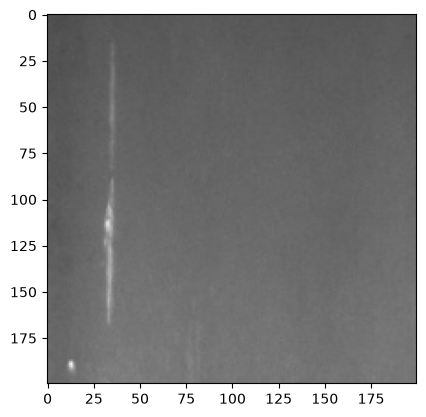

In [8]:
# Display The Image
plt.imshow(img)
plt.show()

# Step3: Understanding Image Properties

In [9]:
# Check The Type
type(img)

numpy.ndarray

In [10]:
# Check Shape
img.shape

(200, 200, 3)

In [11]:
# number of dimensions
img.ndim

3

In [12]:
# Datatype
img.dtype

dtype('uint8')

In [13]:
# Total number of values
img.size

120000

# Step4: Understanding BGR vs RGB (Color Spaces)

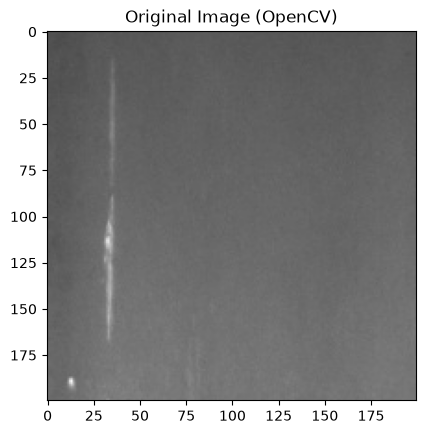

In [14]:
# Display Original Image
plt.imshow(img)
plt.title("Original Image (OpenCV)")
plt.show()

In [15]:
# Convert BGR to RGB
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

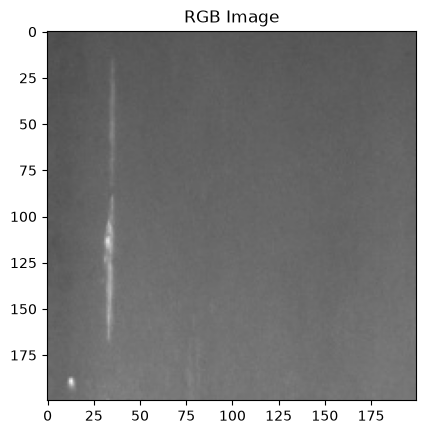

In [16]:
# Display Converted Image
plt.imshow(img_rgb)
plt.title("RGB Image")
plt.show()

In [17]:
print(img[0, 0])

[81 81 81]


In [18]:
print(img_rgb[0, 0])

[81 81 81]


# Step5: Gray Scale Images

In [19]:
# Convert RGB Image to Grayscale

gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

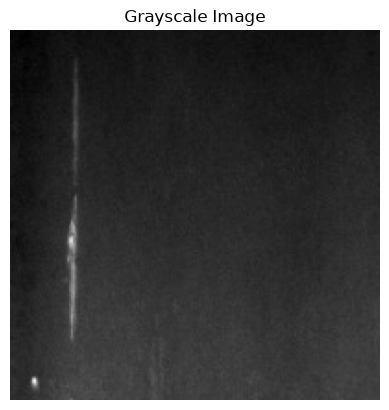

In [20]:
# Display Grayscale Image
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [21]:
gray.shape

(200, 200)

In [22]:
img_rgb.shape

(200, 200, 3)

# Step6: Image Resizing

In [23]:
# Check Original Image Shape
print("Original Shape:", img_rgb.shape)

Original Shape: (200, 200, 3)


In [24]:
# Resize The Image
img_resized = cv2.resize(img_rgb, (224, 224))

In [25]:
# Verify the new shape
print("Resized Shape:", img_resized.shape)

Resized Shape: (224, 224, 3)


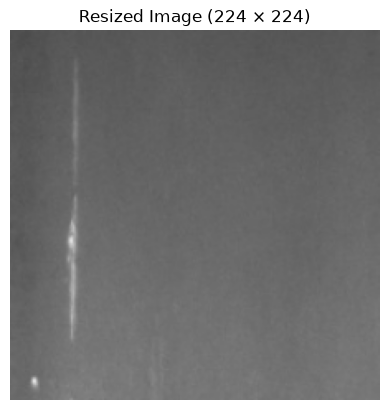

In [26]:
# Display The Resized Image
plt.imshow(img_resized)
plt.title("Resized Image (224 × 224)")
plt.axis("off")
plt.show()

# Step7: Image Normalization

In [27]:
# Check Pixel Values Before Normalization
print("Minimum Pixel Value:", img_resized.min())
print("Maximum Pixel Value:", img_resized.max())

Minimum Pixel Value: 75
Maximum Pixel Value: 230


In [28]:
# Normalize The Image
img_normalized = img_resized / 255.0

In [29]:
# Verify The Result
print("Minimum Pixel Value:", img_normalized.min())
print("Maximum Pixel Value:", img_normalized.max())

Minimum Pixel Value: 0.29411764705882354
Maximum Pixel Value: 0.9019607843137255


In [30]:
# Check Datatype
print(img_resized.dtype)
print(img_normalized.dtype)

uint8
float64


# Step8: Understanding The Complete Dataset

In [31]:
# Lets Verify The Classes
import os

train_path = r"C:\Users\ojass\OneDrive\Documents\Desktop\my\aiml projects\AI-Based Manufacturing Defect Detection using Deep Learning\Dataset\NEU-DET\train\images"

classes = os.listdir(train_path)

print(classes)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [32]:
# Number Of Images In Each Class
for class_name in classes:
    
    class_path = os.path.join(train_path, class_name)

    print(
        class_name,
        "->",
        len(os.listdir(class_path)),
        "images"
    )

crazing -> 240 images
inclusion -> 240 images
patches -> 240 images
pitted_surface -> 240 images
rolled-in_scale -> 240 images
scratches -> 240 images


# Step 9: Loading The Entire Dataset

In [33]:
# Create Empty Lists
X = []
y = []

In [34]:
# Loop Through Every Class
for class_name in classes:

    class_path = os.path.join(train_path, class_name)
    #Loop Through Every Image
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        # Read Image
        img = cv2.imread(image_path)

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize
        img = cv2.resize(img, (224, 224))

        # Normalize
        img = img / 255.0

        # Store Image
        X.append(img)

        # Store Label
        y.append(class_name)

In [35]:
# Verify
print("Total Images :", len(X))
print("Total Labels :", len(y))

Total Images : 1440
Total Labels : 1440


# Step 10: Converting Lists Into Numpy Arrays

In [36]:
print(type(X))

<class 'list'>


In [37]:
print(type(y))

<class 'list'>


In [38]:
# Convert X
X = np.array(X)

In [39]:
# Convert y
y = np.array(y)

In [40]:
# Verify
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [41]:
# Check Dataset Shape
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (1440, 224, 224, 3)
y Shape : (1440,)


In [42]:
# Check Datatype
print(X.dtype)

float64


# Step11: Label Encoding

In [43]:
# Import Label Encoder
from sklearn.preprocessing import LabelEncoder

In [44]:
# Create Encoder
le = LabelEncoder()

In [45]:
# Encode Labels
y = le.fit_transform(y)

In [46]:
# Check The Result
print(y[:10])

[0 0 0 0 0 0 0 0 0 0]


In [47]:
# View Class Mapping
print(le.classes_)

['crazing' 'inclusion' 'patches' 'pitted_surface' 'rolled-in_scale'
 'scratches']


In [48]:
# Demonstration
print(le.inverse_transform([0]))
print(le.inverse_transform([5]))

['crazing']
['scratches']


# Step12: Train/Validation Step

In [49]:
# Import train_test_split
from sklearn.model_selection import train_test_split

In [50]:
# Split The Dataset
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [51]:
# Check Shapes
print("Training Images :", X_train.shape)
print("Validation Images :", X_val.shape)

print("Training Labels :", y_train.shape)
print("Validation Labels :", y_val.shape)

Training Images : (1152, 224, 224, 3)
Validation Images : (288, 224, 224, 3)
Training Labels : (1152,)
Validation Labels : (288,)


# Step13: Building Our CNN

In [52]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [53]:
import cv2
import sklearn
import pandas as pd
import matplotlib

print("TensorFlow :", tf.__version__)
print("OpenCV :", cv2.__version__)
print("Scikit-learn :", sklearn.__version__)
print("Pandas :", pd.__version__)
print("Matplotlib :", matplotlib.__version__)

TensorFlow : 2.21.0
OpenCV : 4.13.0
Scikit-learn : 1.9.0
Pandas : 3.0.3
Matplotlib : 3.11.0


In [54]:
# Import Tensorflow Libraries
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [55]:
# Create CNN Model
model = Sequential()

In [56]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [57]:
from tensorflow.keras.models import Sequential

model = Sequential()

print(model)

<Sequential name=sequential_1, built=False>


# Step 14: Adding the First Convolution Layer

In [58]:
# First Convolution Layer

model.add(

    Conv2D(

        filters=32,

        kernel_size=(3,3),

        activation="relu",

        input_shape=(224,224,3)

    )

)

C:\Users\ojass\.conda\envs\deep_learning\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
# Max Pooling
model.add(

    MaxPooling2D(

        pool_size=(2,2)

    )

)

In [60]:
# Flatten The Model
model.add(

    Flatten()

)

In [61]:
# First Dense Layer
model.add(

    Dense(

        128,

        activation="relu"

    )

)

In [62]:
# Add the Output Layer
model.add(
    Dense(
        6,
        activation="softmax"
    )
)

In [63]:
# Compile The CNN
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [64]:
# Training The CNN
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.2665 - loss: 7.6169 - val_accuracy: 0.3785 - val_loss: 1.4233
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4957 - loss: 1.1288 - val_accuracy: 0.5903 - val_loss: 0.9717
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6771 - loss: 0.8217 - val_accuracy: 0.6389 - val_loss: 0.8203
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7665 - loss: 0.6573 - val_accuracy: 0.6771 - val_loss: 0.7436
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8325 - loss: 0.5072 - val_accuracy: 0.6840 - val_loss: 0.6733
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7769 - loss: 0.6091 - val_accuracy: 0.6424 - val_loss: 0.7391
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 994ms/step - accuracy: 0.8898 - loss: 0.4106 - val_accuracy: 0.8368 - val_loss: 0.4863
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 987ms/step - accuracy: 0.9036 - loss: 0.3126 - val_accuracy: 0.8056 - val

In [65]:
# Evaluation Libraries

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
# Predict on Validation Data

y_pred = model.predict(X_val)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step


In [67]:
y_pred

array([[2.5876509e-03, 1.1253408e-07, 9.2649233e-01, 1.7120543e-05,
        7.0772573e-02, 1.3021661e-04],
       [8.8404083e-01, 4.2393784e-12, 1.1250170e-01, 1.5758116e-07,
        3.4569553e-03, 2.1264316e-07],
       [8.5499954e-01, 1.3760687e-12, 1.4129071e-01, 5.8930380e-07,
        3.7090580e-03, 2.3705120e-07],
       ...,
       [2.8919319e-02, 2.7806418e-10, 9.6123660e-01, 4.0629006e-06,
        9.8355180e-03, 4.4935682e-06],
       [1.0970847e-04, 5.4223329e-04, 8.5307108e-03, 4.3591313e-02,
        9.3833983e-01, 8.8861696e-03],
       [1.0854445e-03, 4.9945466e-08, 9.9324232e-01, 1.0846323e-05,
        5.5581043e-03, 1.0328025e-04]], shape=(288, 6), dtype=float32)

In [68]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)

In [69]:
print(y_pred_classes)

[2 0 0 1 2 3 1 4 0 2 2 1 5 3 2 4 0 3 3 5 0 3 0 1 3 4 4 5 1 0 1 5 4 5 4 1 0
 1 3 2 5 1 3 2 2 1 3 2 5 4 2 2 1 0 1 3 4 0 1 0 0 0 3 0 2 0 2 1 5 1 4 3 5 5
 2 0 5 5 3 2 0 1 4 3 2 2 3 0 1 1 4 1 4 0 4 1 3 0 3 0 4 5 4 3 1 1 1 0 3 1 4
 5 1 1 0 4 0 0 3 3 1 4 2 1 4 1 3 1 4 1 2 3 1 1 5 4 4 4 4 2 1 2 5 4 3 0 5 5
 0 4 2 3 3 2 1 1 2 2 4 5 1 0 3 5 2 3 1 5 3 3 3 1 3 4 4 2 4 1 1 1 4 3 1 2 0
 4 3 1 3 0 5 2 5 2 4 2 3 2 0 4 4 2 5 1 5 2 1 1 1 1 0 4 3 3 3 0 4 4 2 1 1 1
 5 3 2 0 2 3 1 3 4 4 2 1 3 0 4 1 2 5 1 1 4 2 2 4 1 0 5 2 1 2 3 2 2 2 4 2 2
 0 2 0 0 3 0 3 1 3 2 1 1 1 4 0 5 1 0 4 3 1 5 4 4 4 3 2 4 2]


In [70]:
print(y_pred.shape)

(288, 6)


In [71]:
print(y_pred_classes.shape)

(288,)


In [72]:
# Create The Confusion Matrix
cm = confusion_matrix(y_val, y_pred_classes)

print(cm)

[[39  0  9  0  0  0]
 [ 0 41  0  4  0  3]
 [ 3  0 43  1  1  0]
 [ 0  3  0 43  1  1]
 [ 0  0  0  0 48  0]
 [ 0 21  0  1  0 26]]


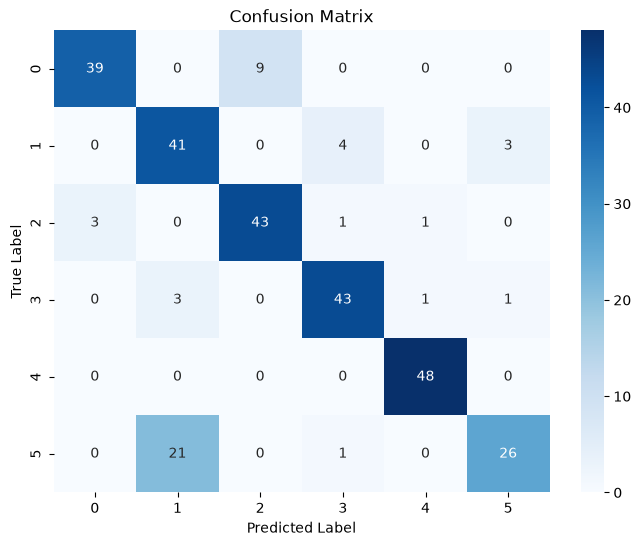

In [73]:
# Visualize
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [74]:
# Classification Report
print(classification_report(y_val, y_pred_classes))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87        48
           1       0.63      0.85      0.73        48
           2       0.83      0.90      0.86        48
           3       0.88      0.90      0.89        48
           4       0.96      1.00      0.98        48
           5       0.87      0.54      0.67        48

    accuracy                           0.83       288
   macro avg       0.85      0.83      0.83       288
weighted avg       0.85      0.83      0.83       288



In [75]:
# Save the Trained CNN Model

model.save("manufacturing_defect_cnn.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [76]:
# Load The Model
from tensorflow.keras.models import load_model

loaded_model = load_model("manufacturing_defect_cnn.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [77]:
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 394272)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      50,466,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,405,844 (577.57 MB)

 Trainable params: 50,468,614 (192.52 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 100,937,230 (385.04 MB)

# Step: Making Predictions on a Completely New Image

In [78]:
# Import Libraries
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

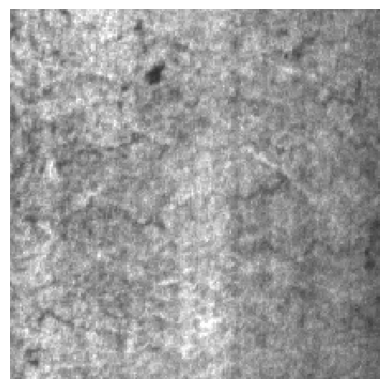

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
Predicted Class : crazing
Confidence : 99.912735 %


In [81]:
# Prediction Code
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# Class Names
class_names = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

# Image Path
img_path = r"C:\Users\ojass\OneDrive\Documents\Desktop\my\aiml projects\AI-Based Manufacturing Defect Detection using Deep Learning\Dataset\NEU-DET\train\images\crazing\crazing_18.jpg"

# Load Image
img = image.load_img(img_path, target_size=(224,224))

# Display Image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert to Array
img_array = image.img_to_array(img)

# Add Batch Dimension
img_array = np.expand_dims(img_array, axis=0)

# Normalize
img_array = img_array / 255.0

# Prediction
prediction = loaded_model.predict(img_array)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

print("Predicted Class :", class_names[predicted_class])
print("Confidence :", confidence*100,"%")

# Plotting Accuracy and Loss

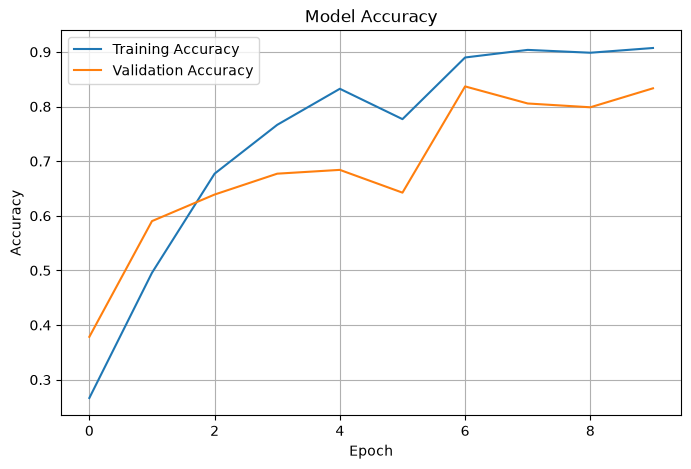

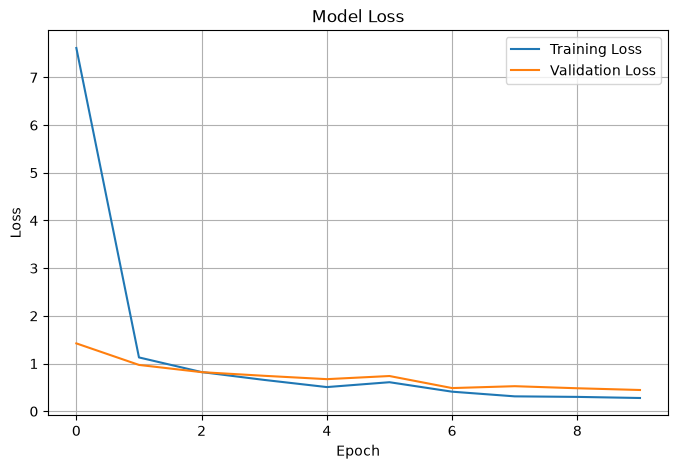

In [82]:
# Plot Accuracy and Loss Graphs

import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Testing On Random Images

In [83]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_defect(img_path):

    img = image.load_img(img_path, target_size=(224,224))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = img_array / 255.0

    prediction = loaded_model.predict(img_array, verbose=0)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    print("Predicted Class :", class_names[predicted_class])
    print("Confidence :", round(confidence*100,2),"%")

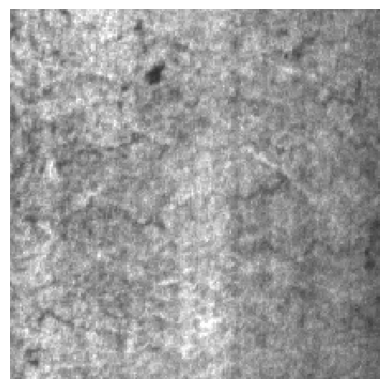

Predicted Class : crazing
Confidence : 99.91 %


In [85]:
predict_defect(r"C:\Users\ojass\OneDrive\Documents\Desktop\my\aiml projects\AI-Based Manufacturing Defect Detection using Deep Learning\Dataset\NEU-DET\train\images\crazing\crazing_18.jpg")

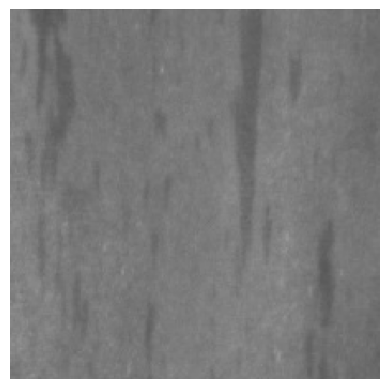

Predicted Class : inclusion
Confidence : 60.83 %


In [86]:
predict_defect(r"C:\Users\ojass\OneDrive\Documents\Desktop\my\aiml projects\AI-Based Manufacturing Defect Detection using Deep Learning\Dataset\NEU-DET\train\images\inclusion\inclusion_18.jpg")

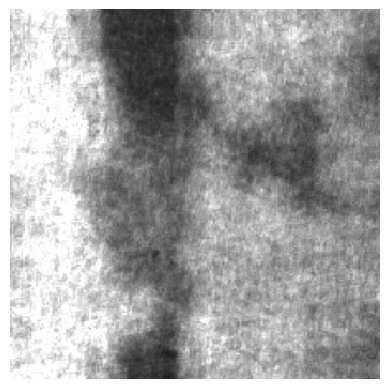

Predicted Class : patches
Confidence : 53.7 %


In [87]:
predict_defect(r"C:\Users\ojass\OneDrive\Documents\Desktop\my\aiml projects\AI-Based Manufacturing Defect Detection using Deep Learning\Dataset\NEU-DET\train\images\patches\patches_18.jpg")

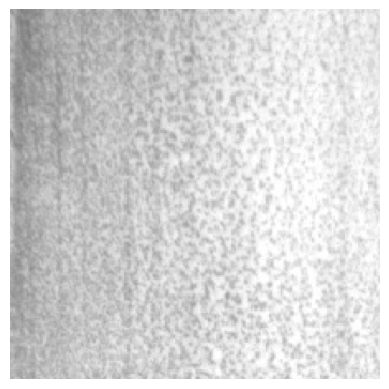

Predicted Class : pitted_surface
Confidence : 93.59 %


In [88]:
predict_defect(r"C:\Users\ojass\OneDrive\Documents\Desktop\my\aiml projects\AI-Based Manufacturing Defect Detection using Deep Learning\Dataset\NEU-DET\train\images\pitted_surface\pitted_surface_18.jpg")

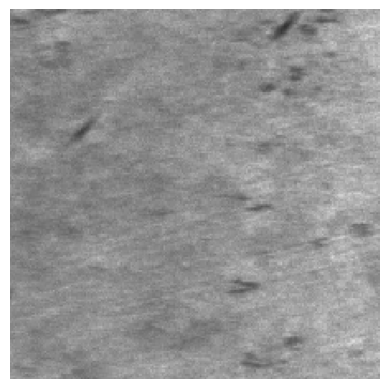

Predicted Class : rolled-in_scale
Confidence : 91.0 %


In [89]:
predict_defect(r"C:\Users\ojass\OneDrive\Documents\Desktop\my\aiml projects\AI-Based Manufacturing Defect Detection using Deep Learning\Dataset\NEU-DET\train\images\rolled-in_scale\rolled-in_scale_18.jpg")

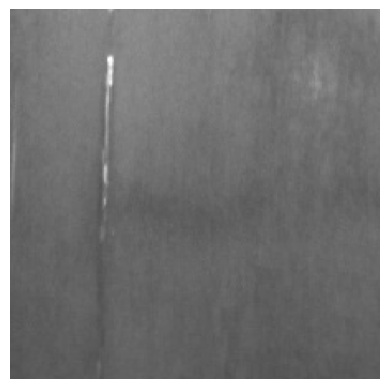

Predicted Class : inclusion
Confidence : 57.8 %


In [90]:
predict_defect(r"C:\Users\ojass\OneDrive\Documents\Desktop\my\aiml projects\AI-Based Manufacturing Defect Detection using Deep Learning\Dataset\NEU-DET\train\images\scratches\scratches_18.jpg")